# 04 — Knowledge Graph Construction & Drug Target Discovery

**Pipeline Step 4 of 5**

Constructs a **Micro-Clinical Knowledge Graph (Micro-CKG)** from the TBI spatial transcriptomics data and enriches it with external biological knowledge.

### Pipeline
1. **Leiden clustering** of spots → proxy cell-type assignments
2. **Wilcoxon DE testing** across clusters → DE-filtered edges (p_adj < 0.05, |log2FC| > 0.5)
3. **Build BioCypher graph** with Gene, CellType, and Region nodes
4. **Spatial validation** via Moran's I autocorrelation
5. **Translational discovery** — mouse→human orthologs, GO enrichment, ChEMBL drug targets

### Inputs
| File | Description |
|---|---|
| `data/processed/tbi_preprocessed.h5ad` | QC-filtered, normalized AnnData from Step 01 |
| `cache/stabl_results_<hash>.pkl` | Stabl results from Step 02 |
| `config/schema_config.yaml` | BioCypher schema mapping |

### Outputs
| File | Description |
|---|---|
| `cache/micro_ckg.graphml` | Serialized Micro-CKG in GraphML format |

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.spatial_pipeline import (
    load_adata, run_stabl_cached, compute_clusters,
    annotate_clusters, assign_injury_labels,
)
from src.biocypher_adapter import build_micro_ckg, save_graph, visualize_graph
from src.spatial_analytics import (
    compute_spatial_neighbors, compute_spatial_autocorr,
    run_nhood_enrichment,
)
from src.external_knowledge import (
    map_orthologs, run_go_enrichment, get_drug_targets,
)
from src.graph_analytics import (
    detect_communities, compute_centrality, find_bridge_genes, summarise_graph,
)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
CACHE_DIR = PROJECT_ROOT / "cache"

print("Imports ready.")

Imports ready.


## 4.1 Load Data and Stabl Results

In [2]:
adata = load_adata(DATA_PROCESSED / "tbi_preprocessed.h5ad")

stabl_result = run_stabl_cached(
    adata,
    cache_dir=CACHE_DIR,
    dataset_name="geo_tbi",
    label_method="condition",
    n_bootstraps=500,
    prefilter="de",
    fdr_alpha=0.01,
    min_log2fc=0.5,
)

print(f"\n{stabl_result['n_selected']} Stabl-selected features loaded.")

  Loading dataset: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/data/processed/tbi_preprocessed.h5ad
  Shape: 24922 spots × 19415 genes
  Loading cached Stabl results: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache/stabl_results_afa34002d272.pkl

2 Stabl-selected features loaded.


## 4.2 Compute Leiden Clusters

Before building the graph, we need cell-type assignments. We apply Leiden community detection (a graph-based clustering algorithm) to the spot-level expression profiles. The procedure is: select highly variable genes, compute PCA (40 components), build a k-nearest-neighbor graph (k=10), and partition the graph using the Leiden algorithm at resolution 0.8.

Each resulting cluster represents a group of spots with similar expression profiles. These clusters serve as proxy cell-type labels (e.g., neuronal subtypes, glial populations) and are used to create CellType nodes in the knowledge graph. The cluster-to-region mapping assigns anatomical labels (Cortex, Hippocampus, Thalamus, etc.) based on cluster rank order, providing spatial context for each cell-type node.

In [3]:
adata = compute_clusters(adata, n_hvgs=2000)
print(f"\nLeiden clusters: {adata.obs['leiden'].nunique()}")
print(adata.obs["leiden"].value_counts().sort_index())

# Annotate clusters with brain-region marker gene signatures
cluster_annotation = annotate_clusters(adata)
print("\nCluster annotations:")
for cid, region in sorted(cluster_annotation.items(), key=lambda x: int(x[0])):
    print(f"  Cluster {cid} → {region}")

# Assign injury labels based on neuroinflammation scoring
injury_labels = assign_injury_labels(adata)
n_reactive = int(injury_labels.sum())
n_homeo = len(injury_labels) - n_reactive
print(f"\nInjury labels: {n_reactive} reactive / {n_homeo} homeostatic spots")

  Selected 2000 highly variable genes (requested 2000)


/Users/shaunfchen/.local/share/uv/python/cpython-3.11.15-macos-aarch64-none/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
python(9713) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Leiden clustering: 29 clusters

Leiden clusters: 29
leiden
0      941
1      679
2     1954
3     1971
4      158
5     2242
6     1044
7      876
8      616
9     1206
10    1309
11     916
12    1511
13     608
14     652
15    1232
16     630
17    1089
18     518
19     203
20     475
21      76
22     299
23     529
24     424
25     937
26     269
27     747
28     811
Name: count, dtype: int64
  Cluster annotation: {'White_Matter': np.int64(14), 'Cortex': np.int64(8), 'Striatum': np.int64(7)}

Cluster annotations:
  Cluster 0 → White_Matter
  Cluster 1 → Cortex
  Cluster 2 → White_Matter
  Cluster 3 → Striatum
  Cluster 4 → Striatum
  Cluster 5 → Striatum
  Cluster 6 → White_Matter
  Cluster 7 → Cortex
  Cluster 8 → Striatum
  Cluster 9 → White_Matter
  Cluster 10 → Cortex
  Cluster 11 → White_Matter
  Cluster 12 → Cortex
  Cluster 13 → White_Matter
  Cluster 14 → White_Matter
  Cluster 15 → White_Matter
  Cluster 16 → White_Matter
  Cluster 17 → Cortex
  Cluster 18 → White_Ma

## 4.3 Build Micro-CKG (DE-Filtered)

The knowledge graph now uses **Wilcoxon rank-sum differential expression testing** to create statistically significant edges instead of simple expression thresholds:

**Filtering criteria:**
- Gene → CellType edges require adjusted p-value < 0.05 AND |log2FC| > 0.5
- Gene → Region edges are aggregated from DE-significant cluster-level associations
- This reduces the graph from ~1000 noisy edges to a sparse, biologically meaningful network

**Edge attributes now include:**
- `log2fc` — log2 fold change from DE test
- `pval_adj` — Benjamini-Hochberg adjusted p-value
- `stability_score` — Stabl bootstrap stability score
- `mean_expression` — mean expression in the cluster

In [4]:
schema_path = PROJECT_ROOT / "config" / "schema_config.yaml"

graph = build_micro_ckg(
    stabl_result=stabl_result,
    adata=adata,
    schema_path=schema_path,
    cluster_annotation=cluster_annotation,
)

print(f"\nMicro-CKG:")
print(f"  Nodes: {graph.number_of_nodes()}")
print(f"  Edges: {graph.number_of_edges()}")

# Quick topology summary
summary = summarise_graph(graph)
print(f"  Density: {summary['density']:.4f}")
print(f"  Components: {summary['n_components']}")

  Running DE testing (Wilcoxon rank-sum)...


/Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/shaunfchen/Documents/Repositories/

  DE results: 58 tests, 33 significant
  Building Micro-CKG...
  Micro-CKG: 34 nodes (2 genes, 29 cell types, 3 regions)
  Micro-CKG: 68 edges (DE-filtered)

Micro-CKG:
  Nodes: 34
  Edges: 68
  Graph summary: 34 nodes, 68 edges, density=0.0606, 1 components
  Density: 0.0606
  Components: 1


## 4.4 Graph Analytics & Drug Discovery Dashboard

Multi-panel visualization showing:
- **Top hub genes** — the most connected biomarkers and their cell-type/region associations
- **Gene × Region heatmap** — which biomarkers are spatially specific to which brain regions
- **Centrality ranking** — PageRank identifies the most influential genes in the network
- **Edge composition** — breakdown of relationship types in the knowledge graph

  Communities: 3 detected via Louvain
  Centrality computed for 34 nodes
  Communities: 3 detected via Louvain
  Bridge genes: 2/2 genes bridge >1 community
Top 10 hub genes by PageRank:
             degree  betweenness  pagerank
gene:Tmbim6      17     0.257576  0.016242
gene:H3f3a       22     0.450758  0.016242

Bridge genes (connect multiple graph communities):
       gene  bridge_score  n_communities_bridged  betweenness
 gene:H3f3a      0.624883                      3     0.450758
gene:Tmbim6      0.357076                      3     0.257576


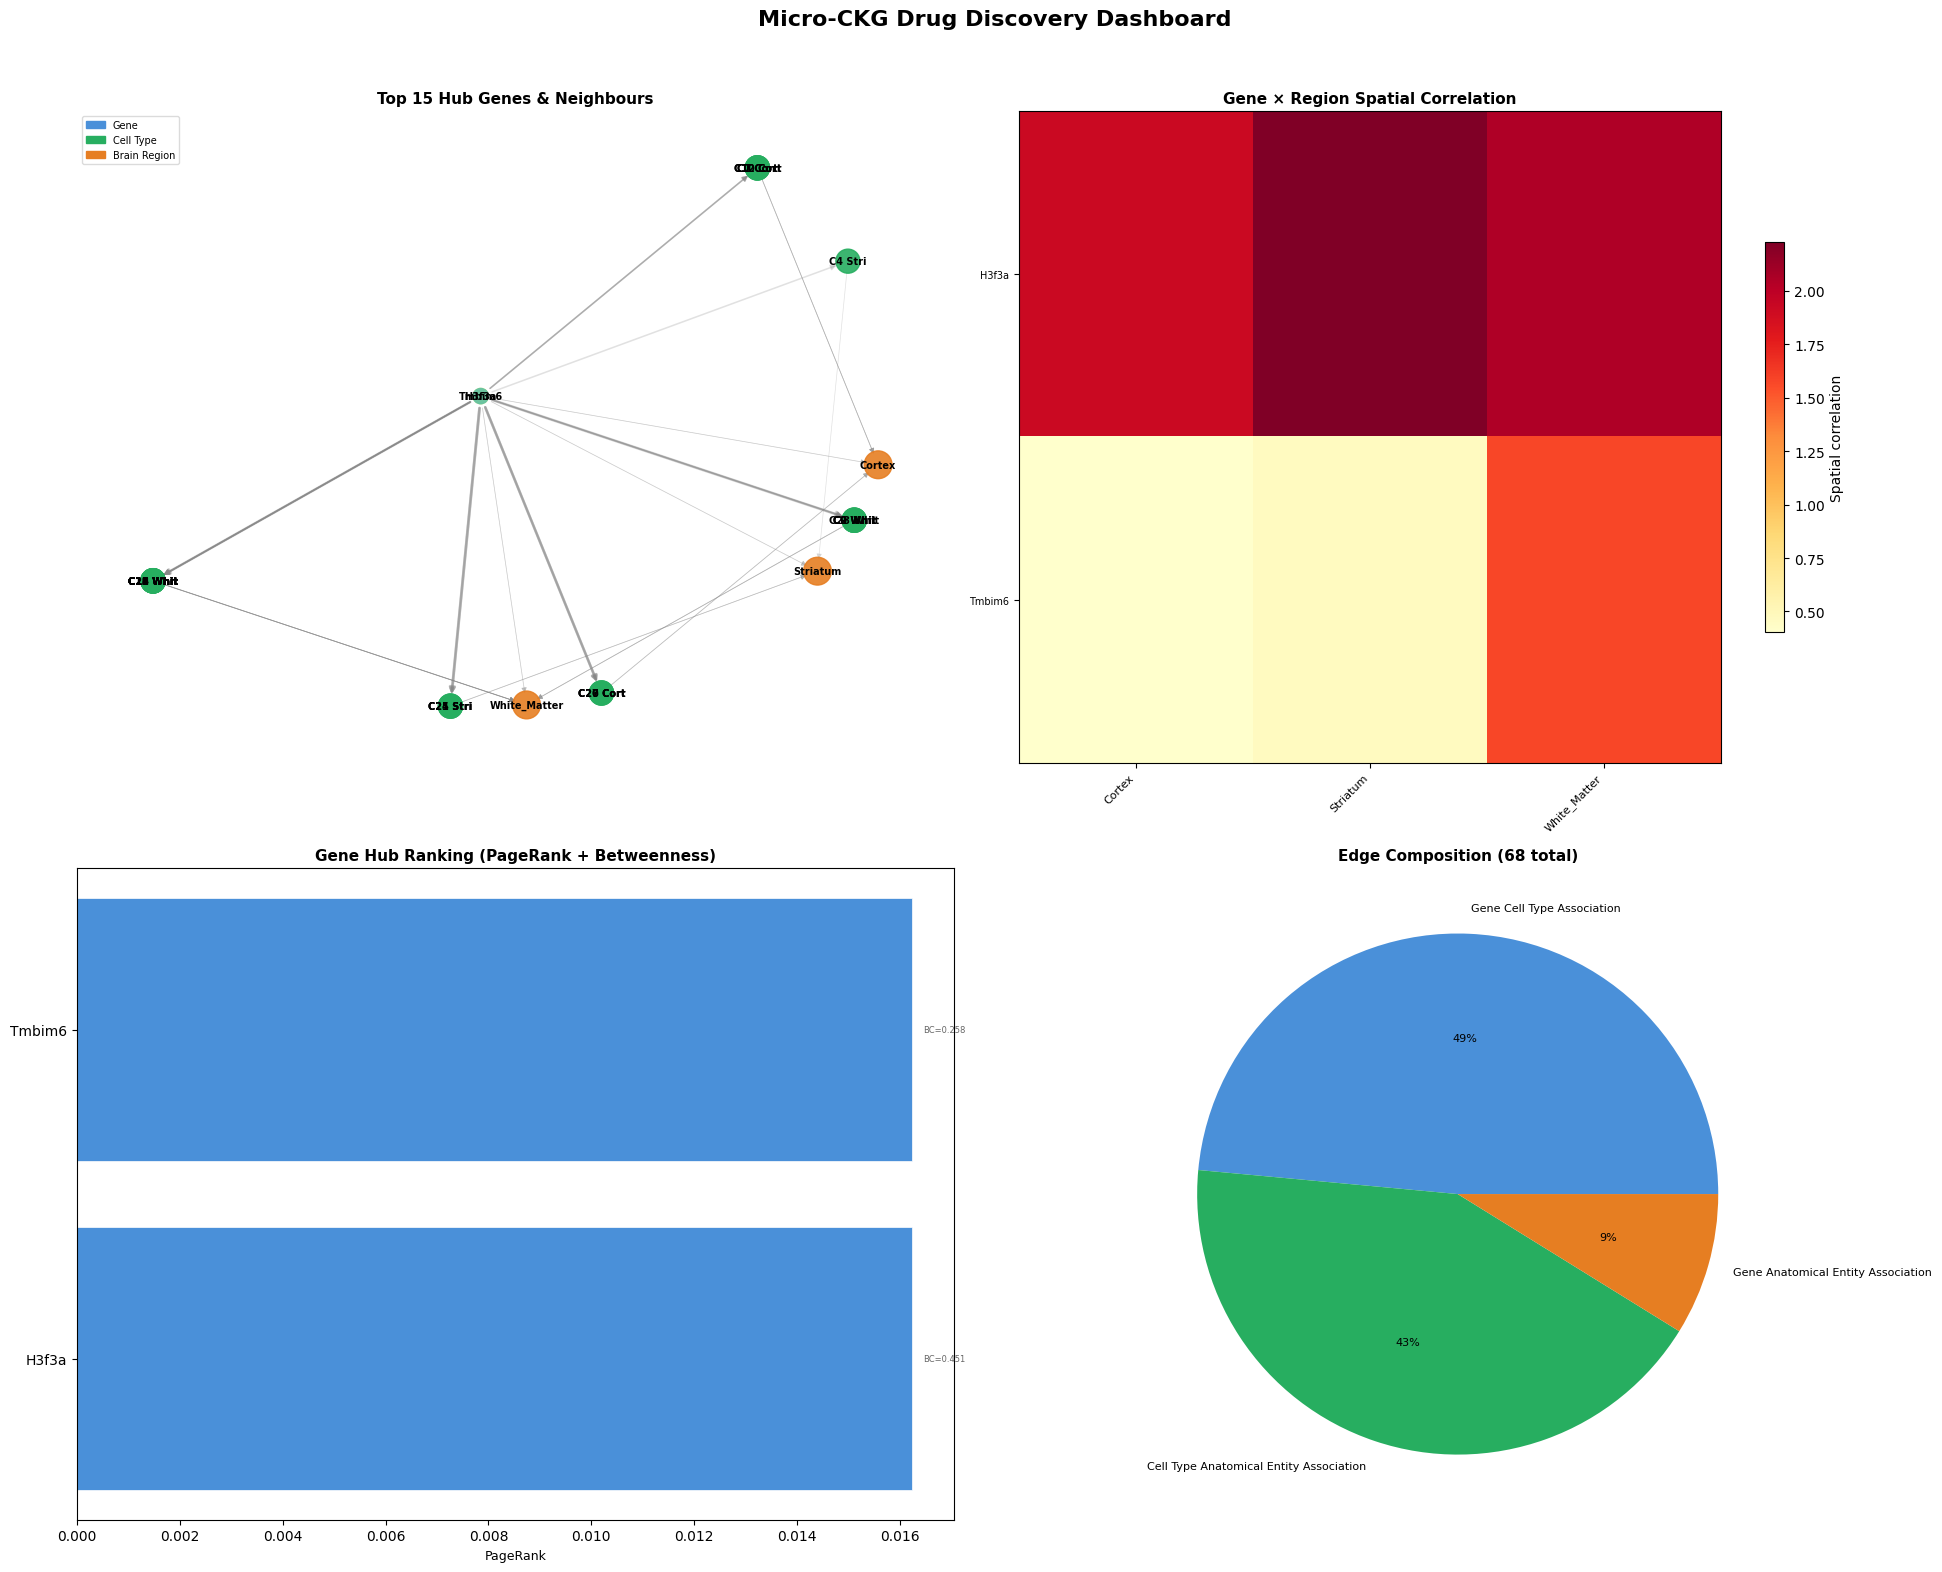

In [5]:
# Community detection & centrality
community_map = detect_communities(graph)
centrality_df = compute_centrality(graph)
bridge_df = find_bridge_genes(graph, centrality_df)

print("Top 10 hub genes by PageRank:")
gene_centrality = centrality_df[centrality_df["label"] == "gene"].head(10)
print(gene_centrality[["degree", "betweenness", "pagerank"]].to_string())

print("\nBridge genes (connect multiple graph communities):")
print(bridge_df.head(10)[["gene", "bridge_score", "n_communities_bridged", "betweenness"]].to_string(index=False))

# Multi-panel drug discovery dashboard
visualize_graph(graph, community_map=community_map, centrality_df=centrality_df)

## 4.5 Save Graph

The Micro-CKG is serialized to GraphML format, a standard XML-based graph format supported by NetworkX, Cytoscape, Neo4j, and other graph analysis tools. This file serves as the input to the LLM agent in Step 05 and can also be loaded into graph visualization software for interactive exploration.

In [6]:
graph_path = save_graph(graph, CACHE_DIR / "micro_ckg.graphml")
print(f"\nGraph persisted: {graph_path}")
print(f"File size: {graph_path.stat().st_size / 1e3:.1f} KB")

  Graph saved to /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache/micro_ckg.graphml

Graph persisted: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache/micro_ckg.graphml
File size: 28.9 KB


## 4.6 Spatial Validation (Moran's I)

**Why this matters for drug development:** A biomarker is only therapeutically relevant if its spatial expression pattern is non-random. Moran's I > 0 with p < 0.05 confirms that a gene shows **spatially clustered expression** — it marks a real tissue compartment, not noise. This spatial specificity is critical for targeted drug delivery.

In [7]:
# Build spatial neighbourhood graph
adata = compute_spatial_neighbors(adata, n_neighs=6)

# Spatial autocorrelation — test Stabl-selected genes
moran_df = compute_spatial_autocorr(
    adata,
    genes=stabl_result["selected_genes"],
    mode="moran",
    n_perms=100,
)

# Show top spatially autocorrelated genes
sig_moran = moran_df[moran_df["pval_norm"] < 0.05].sort_values("I", ascending=False)
print(f"\nTop spatially autocorrelated Stabl genes (Moran's I):")
print(f"({len(sig_moran)}/{len(stabl_result['selected_genes'])} genes spatially significant)\n")
print(sig_moran.head(15)[["I", "pval_norm"]].to_string())

KeyError: 'Spatial basis `spatial` not found in `adata.obsm`.'

## 4.7 Translational Drug Target Discovery

This is the key drug-development step. We take the spatially-validated mouse biomarker genes and:
1. **Map to human orthologs** — mouse gene symbols → human equivalents via HomoloGene
2. **Pathway enrichment** — what GO biological processes / KEGG pathways do these genes converge on?
3. **Drug target query** — which human orthologs have approved or clinical-stage drugs in ChEMBL?

This creates a direct pipeline from spatial transcriptomics → druggable targets.

In [8]:
# Mouse → Human ortholog mapping
ortho_df = map_orthologs(stabl_result["selected_genes"])
human_genes = ortho_df["human_symbol"].dropna().tolist()
print(f"Mapped {len(human_genes)} / {len(stabl_result['selected_genes'])} genes to human orthologs")
display(ortho_df.head(10))

# GO / KEGG pathway enrichment
enrich_df = run_go_enrichment(human_genes)
if enrich_df is not None and not enrich_df.empty:
    print(f"\nTop enriched pathways ({len(enrich_df)} total):")
    display(enrich_df.head(15))
else:
    print("\nNo significant enrichment results returned.")

# ChEMBL drug target lookup
drug_df = get_drug_targets(human_genes)
if drug_df is not None and not drug_df.empty:
    print(f"\nDruggable targets found: {drug_df['gene'].nunique()} genes, {len(drug_df)} drug associations")
    display(drug_df.head(15))
else:
    print("\nNo drug targets found in ChEMBL for these genes.")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
1 input query terms found dup hits:	[('134170', 2)]


  Ortholog mapping: 3/2 genes mapped to human
Mapped 3 / 2 genes to human orthologs


,mouse_symbol,human_symbol,human_entrezgene,ensembl_gene
0,H3f3a,H3-3A,3020,ENSG00000163041
1,H3f3a,H3-3B,3021,ENSG00000132475
2,Tmbim6,TMBIM6,7009,ENSG00000139644


  GO enrichment: 87 significant terms (of 115 total)

Top enriched pathways (115 total):


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Gene_set_library
0,GO_Biological_Process_2023,Negative Regulation Of Cellular Response To Hy...,1/5,0.000750,0.013733,0,0,2499.125000,17982.858998,TMBIM6,GO_Biological_Process_2023
1,GO_Biological_Process_2023,Negative Regulation Of RNA Metabolic Process (...,1/11,0.001649,0.013733,0,0,999.350000,6403.334808,TMBIM6,GO_Biological_Process_2023
2,GO_Biological_Process_2023,Negative Regulation Of Endoplasmic Reticulum S...,1/15,0.002248,0.013733,0,0,713.678571,4351.685757,TMBIM6,GO_Biological_Process_2023
3,GO_Biological_Process_2023,Cellular Response To Unfolded Protein (GO:0034...,1/17,0.002548,0.013733,0,0,624.406250,3729.253306,TMBIM6,GO_Biological_Process_2023
4,GO_Biological_Process_2023,Negative Regulation Of RNA Splicing (GO:0033119),1/19,0.002847,0.013733,0,0,554.972222,3252.888057,TMBIM6,GO_Biological_Process_2023
5,GO_Biological_Process_2023,Negative Regulation Of Calcium Ion Transmembra...,1/19,0.002847,0.013733,0,0,554.972222,3252.888057,TMBIM6,GO_Biological_Process_2023
6,GO_Biological_Process_2023,Cellular Response To Topologically Incorrect P...,1/22,0.003296,0.013733,0,0,475.619048,2718.114680,TMBIM6,GO_Biological_Process_2023
7,GO_Biological_Process_2023,Regulation Of Endoplasmic Reticulum Stress-Ind...,1/24,0.003596,0.013733,0,0,434.217391,2443.769793,TMBIM6,GO_Biological_Process_2023
8,GO_Biological_Process_2023,Negative Regulation Of Response To Endoplasmic...,1/25,0.003745,0.013733,0,0,416.104167,2324.863325,TMBIM6,GO_Biological_Process_2023
9,GO_Biological_Process_2023,Response To Amino Acid (GO:0043200),1/30,0.004493,0.014828,0,0,344.275862,1860.860041,TMBIM6,GO_Biological_Process_2023


  Drug targets: 0 gene-drug associations for 0 genes

No drug targets found in ChEMBL for these genes.
